In [ ]:
import os
DIR = "/content/drive/MyDrive/gtzan/genres_original"
print(os.listdir(DIR))

['classical', 'reggae', 'blues', 'country', 'pop', 'disco', 'metal', 'hiphop', 'jazz', 'rock']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.2971 - loss: 1.9222 - val_accuracy: 0.5662 - val_loss: 1.2126
Epoch 2/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5335 - loss: 1.3403 - val_accuracy: 0.6689 - val_loss: 0.9594
Epoch 3/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6318 - loss: 1.0783 - val_accuracy: 0.7230 - val_loss: 0.8323
Epoch 4/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6907 - loss: 0.9193 - val_accuracy: 0.7437 - val_loss: 0.7558
Epoch 5/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7328 - loss: 0.8091 - val_accuracy: 0.7629 - val_loss: 0.7194
Epoch 6/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7704 - loss: 0.7054 - val_accuracy: 0.8069 - val_loss: 0.6002
Epoch 7/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7959 - loss: 0.6261 - val_accuracy: 0.8074 - val_loss: 0.5925
Epoch 8/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8141 - loss: 0.5734 - val_accuracy: 0.8210 -

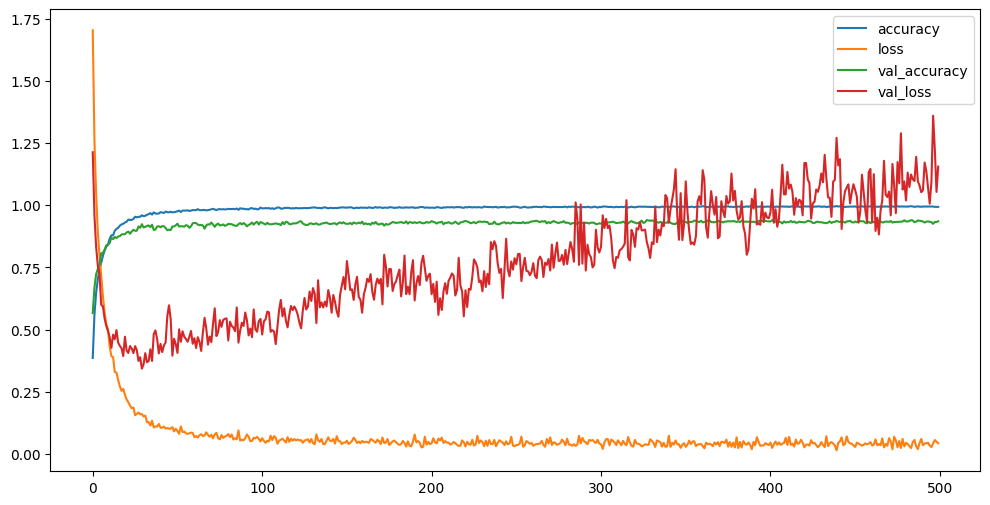

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import keras as k
import joblib
import librosa
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings

SEED = 12

def extract_all_features(file_path, label="unknown", sr=22050, segment_duration=3):
    """
    Trích xuất toàn bộ feature từ file audio theo cấu trúc features_3_sec.csv

    Parameters:
        file_path (str): Đường dẫn file audio
        label (str): Nhãn (thể loại hoặc tên)
        sr (int): Sampling rate
        segment_duration (float): Thời lượng mỗi đoạn tính feature (giây)

    Returns:
        features_list (list): Danh sách các dòng feature
    """
    try:
        # Load file
        y, sr = librosa.load(file_path, sr=sr)
        total_duration = librosa.get_duration(y=y, sr=sr)

        features_list = []
        num_segments = int(total_duration // segment_duration)

        for i in range(num_segments):
            start_sample = int(i * segment_duration * sr)
            end_sample = int(start_sample + segment_duration * sr)
            segment = y[start_sample:end_sample]

            if len(segment) < segment_duration * sr:
                continue

            # Spectral & chroma
            chroma_stft = librosa.feature.chroma_stft(y=segment, sr=sr)
            rms = librosa.feature.rms(y=segment)
            spec_cent = librosa.feature.spectral_centroid(y=segment, sr=sr)
            spec_bw = librosa.feature.spectral_bandwidth(y=segment, sr=sr)
            rolloff = librosa.feature.spectral_rolloff(y=segment, sr=sr)
            zcr = librosa.feature.zero_crossing_rate(segment)

            # Harmonic & percussive
            harmony, perceptr = librosa.effects.hpss(segment)

            # Tempo
            tempo = librosa.beat.tempo(y=segment, sr=sr)[0]

            # MFCC
            mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=20)

            # Build row
            row = [
                os.path.basename(file_path),  # filename # Removed filename from features
                total_duration,               # length
                np.mean(chroma_stft), np.var(chroma_stft),
                np.mean(rms), np.var(rms),
                np.mean(spec_cent), np.var(spec_cent),
                np.mean(spec_bw), np.var(spec_bw),
                np.mean(rolloff), np.var(rolloff),
                np.mean(zcr), np.var(zcr),
                np.mean(harmony), np.var(harmony),
                np.mean(perceptr), np.var(perceptr),
                tempo
            ]

            # Thêm MFCC mean/var
            for m in mfcc:
                row.append(np.mean(m))
                row.append(np.var(m))

            # Label
            row.append(label)

            features_list.append(row)

        return features_list
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return []


def processing_train_data(dir_path):
    processed_data = []
    # The original code was trying to list directories within files, which caused the error.
    # We need to iterate through the files directly within the given directory.
    for genre in os.listdir(dir_path):
        genre_path = os.path.join(dir_path, genre)
        if os.path.isdir(genre_path):
            for filename in os.listdir(genre_path):
                filepath = os.path.join(genre_path, filename)
                # Check if the path is a file before processing
                if os.path.isfile(filepath):
                    # Assuming the directory name is the label
                    label = genre
                    one_song_features = extract_all_features(filepath, label=label)
                    processed_data += one_song_features
    return pd.DataFrame(processed_data)

df = pd.read_csv("/content/drive/MyDrive/gtzan/features_3_sec.csv")
data = df.iloc[1:, :]
y = data.iloc[:, -1]
X = data.iloc[:, 2:-1]

cols = X.columns
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(X)

joblib.dump(min_max_scaler, "min_max_scaler.save")

X_scaled = min_max_scaler.transform(X)

label_index = dict()
index_label = dict()
for i, x in enumerate(df.label.unique()):
    label_index[x] = i
    index_label[i] = x
df.label = [label_index[l] for l in df.label]

df_shuffle = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
df_shuffle.drop(['filename', 'length'], axis=1, inplace=True)
df_y = df_shuffle.pop('label')
df_X = df_shuffle
X_train, df_test_valid_X, y_train, df_test_valid_y = train_test_split(df_X, df_y, train_size=0.7, random_state=SEED, stratify=df_y)
X_dev, X_test, y_dev, y_test = train_test_split(df_test_valid_X, df_test_valid_y, train_size=0.66, random_state=SEED, stratify=df_test_valid_y)

standard_scaler = StandardScaler()
standard_scaler.fit(X_train)
joblib.dump(standard_scaler, "standard_scaler.save")
X_train = pd.DataFrame(standard_scaler.transform(X_train), columns=X_train.columns)
X_dev = pd.DataFrame(standard_scaler.transform(X_dev), columns=X_train.columns)
X_test = pd.DataFrame(standard_scaler.transform(X_test), columns=X_train.columns)


# ACCURACY_THRESHOLD = 0.94

# class myCallback(k.callbacks.Callback):
#     def on_epoch_end(self, epoch, logs={}):
#         if(logs.get('val_accuracy') > ACCURACY_THRESHOLD):
#             print("\n\nStopping training as we have reached %2.2f%% accuracy!" %(ACCURACY_THRESHOLD*100))
#             self.model.stop_training = True

def trainModel(model, epochs, optimizer):
    batch_size = 128
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy']
    )
    return model.fit(X_train, y_train, validation_data=(X_dev, y_dev), epochs=epochs,
                     batch_size=batch_size)

def plotHistory(history):
    print("Max. Validation Accuracy",max(history.history["val_accuracy"]))
    pd.DataFrame(history.history).plot(figsize=(12,6))
    plt.show()


model = k.models.Sequential([
    k.layers.Dense(1024, activation='relu', input_shape=(57,)),
    k.layers.Dropout(0.3),

    k.layers.Dense(512, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(10, activation='softmax'),
])

model_history = trainModel(model=model, epochs=500, optimizer="rmsprop")
model.save_weights('./model.weights.h5')

plotHistory(model_history)


In [ ]:
df

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
0,classical.00000.wav,30.013333,0.255128,0.080380,0.032344,0.000077,1600.635637,18263.944160,1678.586489,20308.453201,...,55.003914,-1.579671,105.558777,4.595662,68.827446,-0.932370,109.457993,4.153583,195.103134,classical
1,classical.00000.wav,30.013333,0.231297,0.084857,0.031277,0.000060,1555.798451,29042.894381,1493.332434,31745.127431,...,52.231808,-1.382555,70.844994,7.217066,67.276711,2.702254,119.502182,-1.754647,150.231812,classical
2,classical.00000.wav,30.013333,0.225399,0.082208,0.041590,0.000227,1467.693833,46547.877941,1497.479727,12363.801278,...,81.793587,-4.620636,101.912674,-4.425995,60.522797,-2.751481,60.382973,2.987761,210.064911,classical
3,classical.00000.wav,30.013333,0.260647,0.082209,0.032538,0.000137,1436.059521,32158.001712,1586.828978,35363.108306,...,39.570984,2.728894,45.162739,-0.717123,58.918007,-8.208592,63.926353,1.747742,118.981697,classical
4,classical.00000.wav,30.013333,0.269903,0.084940,0.045005,0.000482,1479.897733,22720.800426,1572.463383,21801.457287,...,63.477406,-0.112295,91.281517,2.694673,65.245766,-1.274609,104.662666,-4.252006,79.829163,classical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,classical.00089.wav,30.013333,0.186977,0.084423,0.024340,0.000297,2395.835226,95959.322405,1878.412563,18137.093153,...,37.458511,15.027788,54.854614,9.331657,123.270439,-10.744923,200.180832,0.392620,207.307373,classical
994,classical.00089.wav,30.013333,0.221665,0.091501,0.029160,0.000074,2586.177967,51329.453171,1911.330536,11270.698543,...,39.460400,6.688217,37.897049,31.956779,124.712624,3.743584,56.103886,-21.599863,265.835510,classical
995,classical.00089.wav,30.013333,0.230562,0.096133,0.035154,0.000086,2531.291569,33773.446777,1948.714425,10387.708166,...,32.801403,9.402984,32.624367,27.625418,102.953682,-2.933952,93.395882,-17.093946,202.311722,classical
996,classical.00089.wav,30.013333,0.220020,0.086736,0.039235,0.000101,2580.753288,42162.191802,1980.019528,12430.070144,...,27.875937,9.506649,43.077320,21.671856,80.089333,-5.779790,74.287827,-10.424687,136.796860,classical


In [ ]:
y.describe()

,0
count,998.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [ ]:
import numpy as np
import joblib
import librosa
import os

def extract_all_features(file_path, label="unknown", sr=22050, segment_duration=3):
    """
    Trích xuất toàn bộ feature từ file audio theo cấu trúc features_3_sec.csv

    Parameters:
        file_path (str): Đường dẫn file audio
        label (str): Nhãn (thể loại hoặc tên)
        sr (int): Sampling rate
        segment_duration (float): Thời lượng mỗi đoạn tính feature (giây)

    Returns:
        features_list (list): Danh sách các dòng feature
    """
    # Load file
    y, sr = librosa.load(file_path, sr=sr)
    total_duration = librosa.get_duration(y=y, sr=sr)

    features_list = []
    num_segments = int(total_duration // segment_duration)

    for i in range(num_segments):
        start_sample = int(i * segment_duration * sr)
        end_sample = int(start_sample + segment_duration * sr)
        segment = y[start_sample:end_sample]

        if len(segment) < segment_duration * sr:
            continue

        # Spectral & chroma
        chroma_stft = librosa.feature.chroma_stft(y=segment, sr=sr)
        rms = librosa.feature.rms(y=segment)
        spec_cent = librosa.feature.spectral_centroid(y=segment, sr=sr)
        spec_bw = librosa.feature.spectral_bandwidth(y=segment, sr=sr)
        rolloff = librosa.feature.spectral_rolloff(y=segment, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(segment)

        # Harmonic & percussive
        harmony, perceptr = librosa.effects.hpss(segment)

        # Tempo
        tempo = librosa.feature.rhythm.tempo(y=segment, sr=sr)[0]

        # MFCC
        mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=20)

        # Build row
        row = [
            os.path.basename(file_path),  # filename # Removed filename from features
            total_duration,               # length
            np.mean(chroma_stft), np.var(chroma_stft),
            np.mean(rms), np.var(rms),
            np.mean(spec_cent), np.var(spec_cent),
            np.mean(spec_bw), np.var(spec_bw),
            np.mean(rolloff), np.var(rolloff),
            np.mean(zcr), np.var(zcr),
            np.mean(harmony), np.var(harmony),
            np.mean(perceptr), np.var(perceptr),
            tempo
        ]

        # Thêm MFCC mean/var
        for m in mfcc:
            row.append(np.mean(m))
            row.append(np.var(m))

        # Label
        row.append(label)

        features_list.append(row)

    return features_list


# Đọc file audio data
audio_path = "/content/drive/MyDrive/gtzan/genres_original/blues/blues.00003.wav" # Đây là đường dẫn tới file audio

features = extract_all_features(audio_path)
# features = features[2: -1] # This line is no longer necessary as filename and length are not included in features_list anymore

min_max_scaler = joblib.load("min_max_scaler.save")
standard_scaler = joblib.load("standard_scaler.save")

features = [row[2:-1] for row in features] # Remove the label from the features before scaling
features_scaled = min_max_scaler.transform(features)

features_scaled = [row[:] for row in features_scaled]
features_scaled = standard_scaler.transform(features_scaled)

In [ ]:
features

[[np.float32(0.24491636),
  np.float32(0.08458854),
  np.float32(0.089861095),
  np.float32(0.00095687323),
  np.float64(1241.3352367168654),
  np.float64(48304.427695474915),
  np.float64(1609.0657107150896),
  np.float64(24933.65277493643),
  np.float64(2594.5025165264424),
  np.float64(567117.4983745848),
  np.float64(0.04780649038461538),
  np.float64(8.283558681871764e-05),
  np.float32(-0.00041681333),
  np.float32(0.0069756103),
  np.float32(-0.00063599873),
  np.float32(0.0006259044),
  np.float64(103.359375),
  np.float32(-210.31845),
  np.float32(1494.5236),
  np.float32(149.3318),
  np.float32(141.3578),
  np.float32(-9.881604),
  np.float32(294.43228),
  np.float32(52.59583),
  np.float32(76.45517),
  np.float32(-25.678791),
  np.float32(75.778824),
  np.float32(13.964985),
  np.float32(39.7461),
  np.float32(-12.528014),
  np.float32(50.120903),
  np.float32(-13.233246),
  np.float32(88.7081),
  np.float32(-8.571623),
  np.float32(77.41331),
  np.float32(-2.5735247),
  np.

In [ ]:
import numpy as np
import tensorflow as tf
import keras as k

index_label = {0: 'blues', 1: 'classical', 2: 'country', 3: 'disco', 4: 'hiphop', 5: 'jazz', 6: 'metal', 7: 'pop', 8: 'reggae', 9: 'rock'}

model = k.models.Sequential([
    k.layers.Dense(1024, activation='relu', input_shape=(57,)),
    k.layers.Dropout(0.3),

    k.layers.Dense(512, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(10, activation='softmax'),
])

model.load_weights('./model.weights.h5')

pred_proba = model.predict(features_scaled)
pred_class = np.argmax(pred_proba, axis=1)
print(index_label[pred_class[0]])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
classical


In [ ]:
for d in X_test.values:
    p = model.predict(np.expand_dims(d, axis=0)) # Reshape the input to match the expected input shape of the model
    c = np.argmax(p, axis=1)
    print(index_label[c[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
metal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
jazz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
jazz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
classical
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
metal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
jazz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
classical
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
pop
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
hiphop
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
jazz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
metal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
country
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
pop
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
jazz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
classical
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
pop
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
metal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
hiphop
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
metal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
disco
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
metal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
metal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0